# 흉부 X-ray 폐렴 진단 CNN 실습
**목표**: 흉부 X-ray 영상에서 폐렴(Pneumonia) 환자와 정상(Normal)을 구분하는 CNN을 직접 설계하고 학습시킨다.

**데이터셋**: Kermany et al. (2018), *Cell* — Chest X-Ray Images (Pneumonia)- Kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia- 약 5,856장의 소아 흉부 X-ray (정상 vs 폐렴)- 폴더 구조: `chest_xray/{train, val, test}/{NORMAL, PNEUMONIA}`

**환경**: Google Colab (GPU 런타임 필요)- 상단 메뉴: `런타임 → 런타임 유형 변경 → 하드웨어 가속기: GPU (T4)`

**학습 흐름**1. Google Drive 마운트 및 데이터 경로 확인2. 데이터 로딩 및 전처리3. CNN 모델 직접 설계 (from scratch)4. 학습 및 검증5. 테스트셋 평가 (정확도, 민감도, 특이도, 혼동행렬)6. 예측 결과 시각화

## 1. Google Drive 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive가 마운트되면 `/content/drive/MyDrive/` 아래에 본인 드라이브가 보인다.**(선택) zip 파일로 올렸을 경우 압축 풀기** — Drive에 풀면 느리므로 Colab 로컬(`/content/`)에 푸는 것이 훨씬 빠르다.

In [2]:
# 데이터를 .zip 형태로 Drive에 올린 경우만 실행
# (이미 폴더 형태로 올렸다면 이 셀은 건너뛴다)

import os
ZIP_PATH = '/content/drive/MyDrive/archive.zip'  # 본인 경로로 수정
EXTRACT_TO = '/content/data'

if os.path.exists(ZIP_PATH) and not os.path.exists(EXTRACT_TO):
    !unzip -q "$ZIP_PATH" -d $EXTRACT_TO
    print('압축 해제 완료')
else:
    print('이미 풀려있거나 zip 파일이 없음')

압축 해제 완료


## 2. 라이브러리 및 데이터 경로 설정

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 재현성을 위한 random seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU 확인
print('TensorFlow 버전:', tf.__version__)
print('사용 가능한 GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow 버전: 2.20.0
사용 가능한 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# 데이터 경로 설정 — 본인 환경에 맞게 수정
# 옵션 A) Drive에 폴더 형태로 올린 경우
#BASE_DIR = '/content/drive/MyDrive/chest_xray'

# 옵션 B) zip을 /content/data에 푼 경우
BASE_DIR = '/content/data/chest_xray'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

# 각 폴더의 이미지 개수 확인
for split, path in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    n_normal = len(os.listdir(os.path.join(path, 'NORMAL')))
    n_pneum  = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    print(f'{split:6s}  NORMAL={n_normal:4d}  PNEUMONIA={n_pneum:4d}  TOTAL={n_normal+n_pneum:4d}')

train   NORMAL=1341  PNEUMONIA=3875  TOTAL=5216
val     NORMAL=   8  PNEUMONIA=   8  TOTAL=  16
test    NORMAL= 234  PNEUMONIA= 390  TOTAL= 624


**관찰 포인트**- `val` 폴더는 단 16장뿐이라 검증 결과가 불안정하다. → 실제 연구에서는 train의 일부를 떼서 validation으로 쓰는 것이 권장된다.- `train`에는 PNEUMONIA가 NORMAL보다 약 3배 많다 (클래스 불균형). → 학습 시 `class_weight`로 보정한다.

## 3. 샘플 이미지 미리 보기방사선 영상 데이터를 다룰 때는 항상 **데이터 자체를 눈으로 확인**하는 습관이 중요하다.

/tmp/ipykernel_677/2058491005.py:12: UserWarning: Glyph 55113 (\N{HANGUL SYLLABLE HYUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/2058491005.py:12: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/2058491005.py:12: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/2058491005.py:12: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/2058491005.py:12: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/2058491005.py:12: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/2058491005.py:12: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

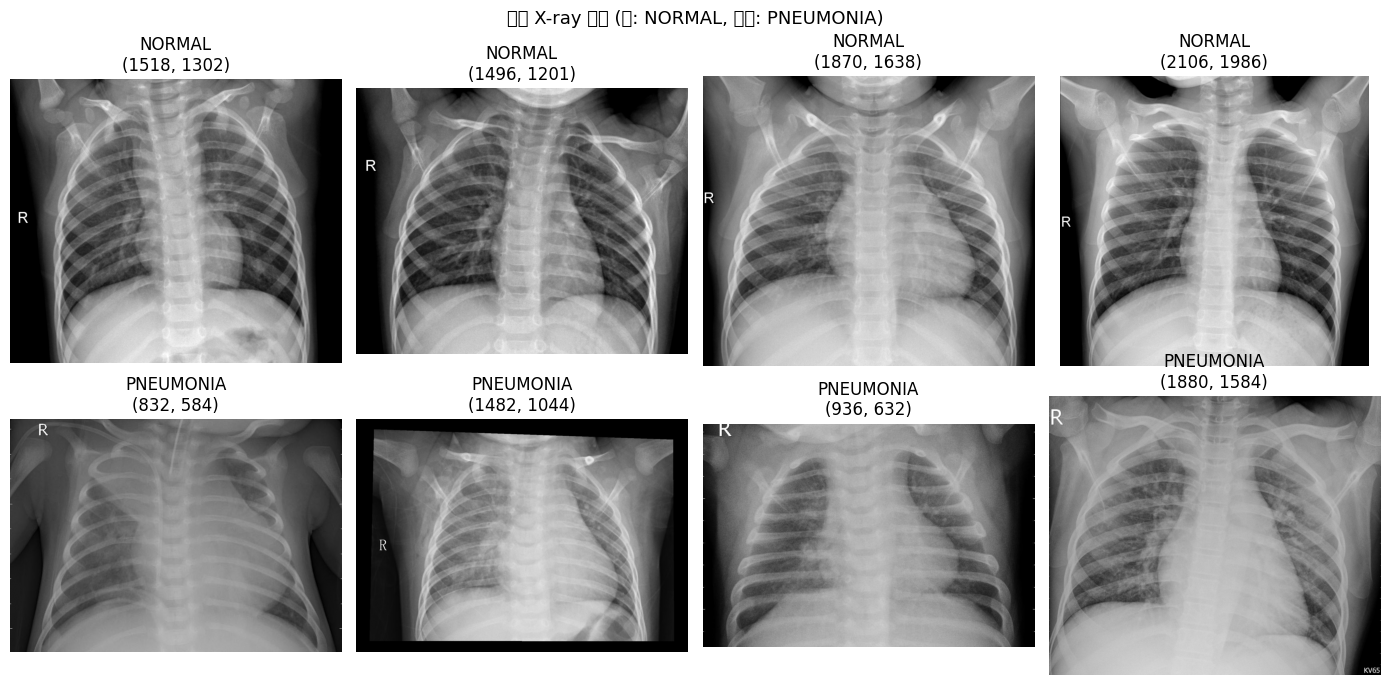

In [5]:
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    files = os.listdir(os.path.join(TRAIN_DIR, cls))[:4]
    for j, f in enumerate(files):
        img = Image.open(os.path.join(TRAIN_DIR, cls, f))
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(f'{cls}\n{img.size}')
        axes[i, j].axis('off')
plt.suptitle('흉부 X-ray 샘플 (위: NORMAL, 아래: PNEUMONIA)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. 데이터 전처리 및 로더 만들기

**전처리 전략**- 이미지 크기: 150×150 (작게 시작 — 학습이 빠르고 GPU 메모리 부담이 적음)- 픽셀값: 0~255 → 0~1로 정규화- 데이터 증강(Augmentation): train 데이터에만 적용 (회전, 줌, 평행이동)- val/test에는 증강 없이 정규화만 적용`ImageDataGenerator`는 Keras에서 제공하는 가장 직관적인 이미지 로더이다. 폴더 구조만 정리되어 있으면 자동으로 라벨을 부여한다.

In [6]:
IMG_SIZE = 150
BATCH_SIZE = 32

# 학습 데이터: 정규화 + 데이터 증강
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,        # ±10도 회전
    zoom_range=0.1,           # ±10% 줌
    width_shift_range=0.1,    # ±10% 좌우 이동
    height_shift_range=0.1,   # ±10% 상하 이동
    horizontal_flip=False     # X-ray는 좌우 비대칭(심장 위치)이므로 flip 비활성화
)

# 검증/테스트 데이터: 정규화만
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',   # X-ray는 흑백이므로 채널 1개로 충분
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

print('\n클래스 인덱스:', train_gen.class_indices)
# {'NORMAL': 0, 'PNEUMONIA': 1} 임을 기억해두자.

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

클래스 인덱스: {'NORMAL': 0, 'PNEUMONIA': 1}


**중요**: `class_indices`를 보면 `NORMAL=0`, `PNEUMONIA=1`이다.즉 모델 출력값이 1에 가까울수록 폐렴, 0에 가까울수록 정상으로 해석한다.방사선 진단에서 우리가 가장 중요시하는 지표:- **민감도(Sensitivity, Recall)** = TP / (TP + FN) → 폐렴 환자를 놓치지 않는 능력- **특이도(Specificity)** = TN / (TN + FP) → 정상을 정상으로 판별하는 능력

## 5. CNN 모델 설계 (From Scratch)이번 실습의 핵심이다. 사전학습 모델(transfer learning)을 쓰지 않고,
**CNN의 기본 구성요소만으로 직접 쌓아본다**.

**설계 원칙**- Conv → BatchNorm → ReLU → MaxPool 블록을 반복- 점점 깊어질수록 채널 수는 늘리고(32→64→128), feature map 크기는 줄인다- 마지막에 Flatten → Dense → Dropout → Sigmoid(이진분류)- 파라미터 수가 너무 많으면 과적합되므로, Dense 층의 노드 수를 적절히 제한

**왜 이런 구조인가?**- Conv는 영상의

**국소적 패턴**(폐 조직 음영의 거칠기 등)을 학습한다- Pool은 위치 변화에 대한

**공간적 강인성**을 부여한다- BatchNorm은 학습을 안정화시키고 수렴을 빠르게 한다- Dropout은 과적합을 억제한다

In [7]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    """학생 실습용 5-block CNN을 처음부터 구성한다."""
    model = models.Sequential(name='ChestXray_CNN_FromScratch')

    # ----- Block 1 -----
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # ----- Block 2 -----
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # ----- Block 3 -----
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # ----- Block 4 -----
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # ----- Classifier head -----
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))   # 이진분류 → 출력 1개

    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ChestXray_CNN_FromScratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,458,113 (5.56 MB)

 Trainable params: 1,457,537 (5.56 MB)

 Non-trainable params: 576 (2.25 KB)

**확인 사항**- `Output Shape` 열을 따라가며 영상이 어떻게 줄어드는지 관찰: 150 → 75 → 37 → 18 → 9- `Param #` 열에서 어디에 파라미터가 가장 많이 몰려있는지 확인 (보통 Flatten 직후 Dense)

## 6. 모델 컴파일- **Loss**: `binary_crossentropy` (이진 분류의 표준)- **Optimizer**: Adam (learning rate 1e-4, 기본값보다 약간 작게)- **Metrics**: 정확도 외에 AUC도 함께 추적 (의료영상에서는 ROC-AUC가 표준 지표)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

## 7. 클래스 가중치 (Class Imbalance 대응)train 데이터의 폐렴 영상이 정상보다 약 3배 많다.→ 모델이 "전부 폐렴"으로만 예측해도 정확도가 75%가 나오는 함정에 빠질 수 있다.→ 적은 쪽(NORMAL)에 더 큰 가중치를 줘서 균형을 맞춘다.

In [9]:
from sklearn.utils.class_weight import compute_class_weight

y_train = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print('클래스 가중치:', class_weight_dict)
# {0: NORMAL 가중치, 1: PNEUMONIA 가중치} — NORMAL 쪽이 더 클 것이다.

클래스 가중치: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## 8. 콜백 설정- **EarlyStopping**: val_loss가 개선되지 않으면 학습을 일찍 종료- **ReduceLROnPlateau**: val_loss가 정체되면 learning rate를 줄여 더 정교하게 학습- **ModelCheckpoint**: 검증 성능이 가장 좋았던 가중치를 저장

In [10]:
os.makedirs('/content/checkpoints', exist_ok=True)

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        '/content/checkpoints/best_model.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

## 9. 학습 실행T4 GPU 기준 약 epoch당 약 1~2분

In [11]:
EPOCHS = 1

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7583 - auc: 0.8394 - loss: 0.5471
Epoch 1: val_auc improved from None to 0.37500, saving model to /content/checkpoints/best_model.keras

Epoch 1: finished saving model to /content/checkpoints/best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 316ms/step - accuracy: 0.8384 - auc: 0.9158 - loss: 0.3801 - val_accuracy: 0.5000 - val_auc: 0.3750 - val_loss: 2.0627 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.


## 10. 학습 곡선 시각화- Loss와 Accuracy가 함께 수렴하는지 확인- train과 val 사이의 격차가 너무 크면 과적합 → 데이터 증강을 늘리거나 Dropout을 키워야 한다

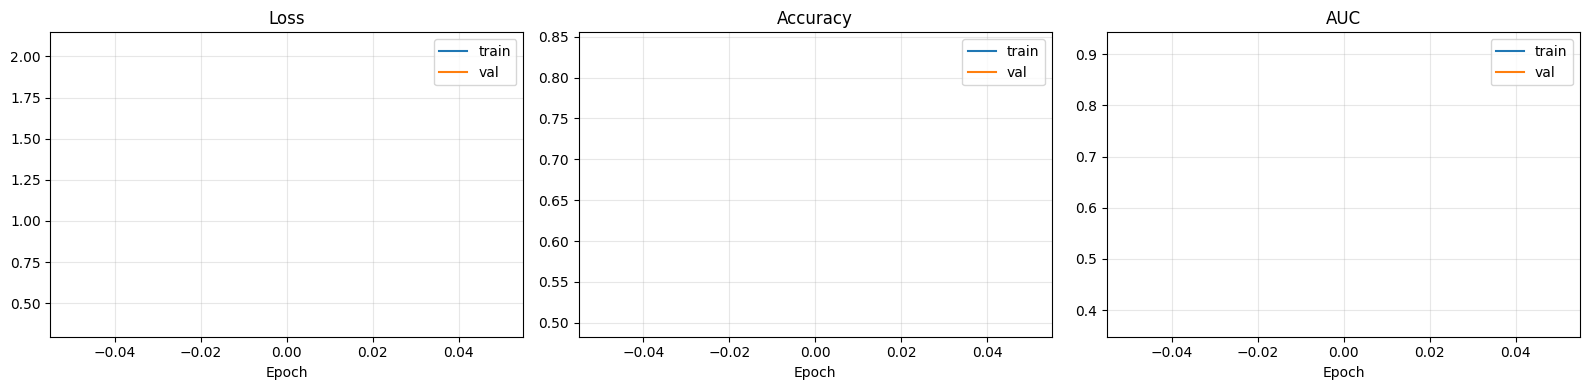

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history.history['auc'], label='train')
axes[2].plot(history.history['val_auc'], label='val')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 테스트셋 평가학습에 한 번도 쓰이지 않은 test 데이터로 최종 성능을 측정한다.

In [13]:
test_loss, test_acc, test_auc = model.evaluate(test_gen, verbose=1)
print(f'\n테스트 결과')
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}')
print(f'  AUC       : {test_auc:.4f}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.6250 - auc: 0.5135 - loss: 1.5412

테스트 결과
  Loss      : 1.5412
  Accuracy  : 0.6250
  AUC       : 0.5135


## 12. 혼동행렬 & 민감도/특이도방사선 진단 분야에서는 **단순 정확도보다 민감도/특이도/AUC**가 훨씬 중요하다.- 폐렴을 놓치는 것(False Negative)은 환자에게 치명적- 정상을 폐렴으로 오진(False Positive)하면 불필요한 항생제 처방으로 이어짐

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 테스트셋 예측
y_pred_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_gen.classes

# 혼동행렬
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)   # = Recall
specificity = TN / (TN + FP)
precision   = TP / (TP + FP)
f1 = 2 * precision * sensitivity / (precision + sensitivity)

print('혼동행렬')
print(f'              예측:NORMAL  예측:PNEUMONIA')
print(f'실제:NORMAL      {TN:6d}        {FP:6d}')
print(f'실제:PNEUMONIA   {FN:6d}        {TP:6d}')
print()
print(f'민감도 (Sensitivity / Recall)  : {sensitivity:.4f}')
print(f'특이도 (Specificity)           : {specificity:.4f}')
print(f'정밀도 (Precision)             : {precision:.4f}')
print(f'F1 score                       : {f1:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step
혼동행렬
              예측:NORMAL  예측:PNEUMONIA
실제:NORMAL           0           234
실제:PNEUMONIA        0           390

민감도 (Sensitivity / Recall)  : 1.0000
특이도 (Specificity)           : 0.0000
정밀도 (Precision)             : 0.6250
F1 score                       : 0.7692

              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


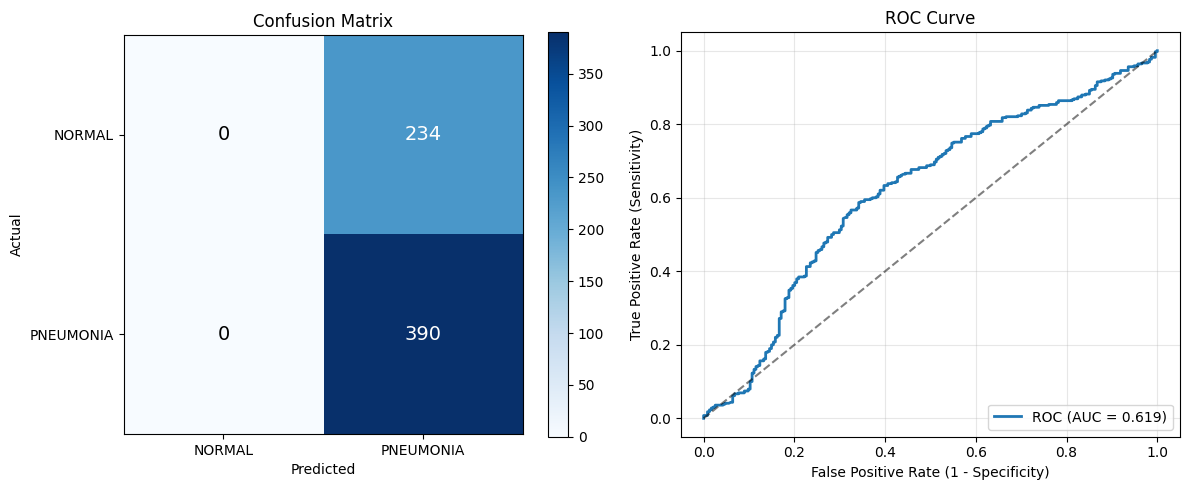

In [15]:
# 혼동행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 왼쪽: 혼동행렬 히트맵
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['NORMAL', 'PNEUMONIA'])
axes[0].set_yticklabels(['NORMAL', 'PNEUMONIA'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black',
                     fontsize=14)
plt.colorbar(im, ax=axes[0])

# 오른쪽: ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. 예측 결과 샘플 시각화모델이 어떤 영상을 맞추고 틀리는지 직접 확인해보자.

/tmp/ipykernel_677/3688428449.py:20: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/3688428449.py:20: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/3688428449.py:20: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/3688428449.py:20: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/3688428449.py:20: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/3688428449.py:20: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/3688428449.py:20: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layou

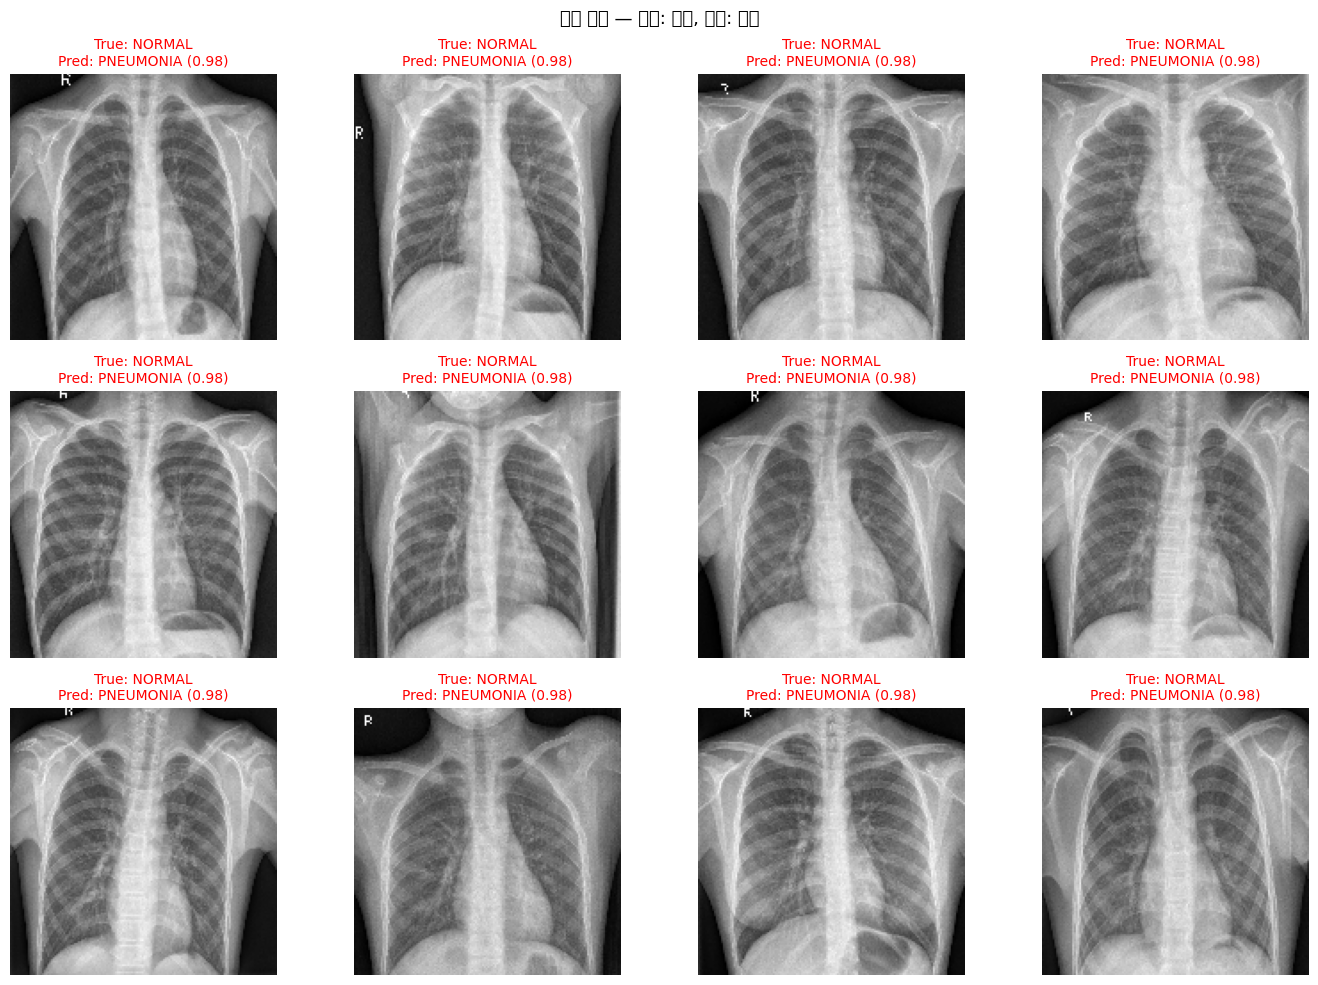

In [16]:
# 테스트셋에서 일부 이미지를 가져와 예측 시각화
test_gen.reset()
batch_x, batch_y = next(test_gen)
batch_pred = model.predict(batch_x, verbose=0).ravel()

class_names = ['NORMAL', 'PNEUMONIA']
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in enumerate(axes.flatten()):
    if i >= len(batch_x): break
    img = batch_x[i].squeeze()
    true_label = class_names[int(batch_y[i])]
    pred_label = class_names[int(batch_pred[i] > 0.5)]
    prob = batch_pred[i]
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({prob:.2f})',
                 color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('예측 결과 — 초록: 정답, 빨강: 오답', fontsize=13)
plt.tight_layout()
plt.show()

## 14. 모델 저장 (선택)학습된 모델을 Drive에 저장해두면 다음 실습에서 바로 불러와 쓸 수 있다.

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/chest_xray_cnn_model.keras'
model.save(SAVE_PATH)
print(f'모델 저장 완료: {SAVE_PATH}')

# 나중에 불러올 때:
# loaded_model = tf.keras.models.load_model(SAVE_PATH)

## 토의주제

**임계값(threshold)을 0.5에서 바꾸면** 민감도/특이도가 어떻게 변하는지 직접 실험하라.   - 힌트: `y_pred = (y_pred_prob > 0.3).astype(int)` 처럼 바꿔서 다시 평가3.

**데이터 증강 옵션을 끄거나 늘리면** 어떻게 달라지는가? (horizontal_flip을 켜면 왜 성능이 나빠지는가?)4.

**모델을 더 깊게/얕게** 만들면 어떻게 되는가? Block을 추가/제거해서 비교하라.5. 이 모델이 다른 병원의 X-ray에도 잘 작동할까? (도메인 시프트 문제 — 영상 획득 장비/프로토콜 차이)

** 더 나아가기- 전이학습(Transfer Learning): ImageNet 사전학습된 VGG16/ResNet50을 가져와 비교- Grad-CAM: 모델이 영상의 어느 부위를 보고 판단하는지 시각화- 3-클래스 분류: PNEUMONIA를 다시 bacterial/viral로 세분화- 다른 방사선 영상으로 확장: COVID-19, 결핵, LIDC 폐결절 CT 등